In [2]:
import os
from itertools import chain

In [7]:
%run Agent.ipynb

In [4]:
# initialize the parameters

my_path = "/Users/jiten/Masters/WorkPlace/"
folder_path = os.getcwd() #"/Users/jiten/Masters/WorkPlace/MRI_MULTI_IMAGE_SEGMENTATION/"

folder_path = os.path.dirname(folder_path)

print(folder_path)


train_dir_dict = {}
test_dir_dict ={}
val_dir_dict ={}

train_dir_edema_SAGIR = os.path.join(folder_path, "train_data_edema_SAGIR")
test_dir_edema_SAGIR = os.path.join(folder_path, "test_data_edema_SAGIR")
val_dir_edema_SAGIR = os.path.join(folder_path, "val_data_edema_SAGIR")

train_dir_frac_SAGIR = os.path.join(folder_path, "train_data_frac_SAGIR")
test_dir_frac_SAGIR = os.path.join(folder_path, "test_data_frac_SAGIR")
val_dir_frac_SAGIR = os.path.join(folder_path, "val_data_frac_SAGIR")

# train_dir_dict['SAGT1'] = train_dir_SAGT1
train_dir_dict['EDEMA'] = train_dir_edema_SAGIR
train_dir_dict['FRAC'] = train_dir_frac_SAGIR

# test_dir_dict['SAGT1'] = test_dir_SAGT1
test_dir_dict['EDEMA'] = test_dir_edema_SAGIR
test_dir_dict['FRAC'] = test_dir_frac_SAGIR

# val_dir_dict['SAGT1'] = val_dir_SAGT1
val_dir_dict['EDEMA'] = val_dir_edema_SAGIR
val_dir_dict['FRAC'] = val_dir_frac_SAGIR

# create the data structure for mask directories
train_mask_dir_dict = {}
test_mask_dir_dict = {}
val_mask_dir_dict = {}

train_mask_edema_SAGIR = os.path.join(folder_path, "train_mask_edema_SAGIR")
test_mask_edema_SAGIR = os.path.join(folder_path, "test_mask_edema_SAGIR")
val_mask_edema_SAGIR = os.path.join(folder_path, "val_mask_edema_SAGIR")

train_mask_dir_dict['EDEMA'] = train_mask_edema_SAGIR
test_mask_dir_dict['EDEMA'] = test_mask_edema_SAGIR
val_mask_dir_dict['EDEMA'] = val_mask_edema_SAGIR

train_mask_frac_SAGIR = os.path.join(folder_path, "train_mask_frac_SAGIR")
test_mask_frac_SAGIR = os.path.join(folder_path, "test_mask_frac_SAGIR")
val_mask_frac_SAGIR = os.path.join(folder_path, "val_mask_frac_SAGIR")

train_mask_dir_dict['FRAC'] = train_mask_frac_SAGIR
test_mask_dir_dict['FRAC'] = test_mask_frac_SAGIR
val_mask_dir_dict['FRAC'] = val_mask_frac_SAGIR


/Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation


### filter size 16-32-64-128-256

In [5]:
# initialize the 
img = 'SAGIR'
imgType = 'EDEMA'
train_flag = True

In [36]:
# initialize the directory and get the model
if train_flag:
    train_dir = train_dir_dict[imgType]
    mask_dir = train_mask_dir_dict[imgType]

    val_dir = val_dir_dict[imgType]
    mask_dir_val = val_mask_dir_dict[imgType]

    # initialize agent
    agent = Agent(train_flag,img_dir=train_dir,msk_dir=mask_dir,folder_path=folder_path, val_dir=val_dir, msk_dir_val=mask_dir_val, 
                  state='new', num_epochs=200, batchSize=30, bilinear=False)
    agent.initializeUnet()

     # load custom dataset
    train_loader, val_loader = agent.loadCustomData()

mps
Initialize Custom Data
Augmentation ::: False
Train flag:: True
loader root directory:: /Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation/train_data_edema_SAGIR
Total Size ::: 559
Initialize Custom Data
Total Size val::: 116


In [37]:
# check the model
agent.model

UNet(
  (encoder1): Res2NetSEBlock(
    (res2net): Res2NetBlock(
      (convs): ModuleList(
        (0): Conv2d(1, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1-3): 3 x Conv2d(2, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (conv_out): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (se): SEBlock(
      (fc1): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
      (fc2): Conv2d(1, 8, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (encoder2): Res2NetSEBlock(
    (res2net): Res2NetBlock(
      (convs): ModuleList(
        (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1-3): 3 x Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (conv_out): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (s

In [38]:
# run the model and get the predictions
if train_flag:
    # run the model
    loss_df, prediction_batch, iou_sore_df, loss_val_df, iou_score_val_df, prediction_batch_val = agent.runModel(train_loader, val_loader, 
                                                                                                            earlyStop=True)
                                                                                                            

Epoch [1/200], Train( Loss: 0.2262, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.2310, IoU_score: 0.0454 )
Epoch [2/200], Train( Loss: 0.2115, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.2096, IoU_score: 0.0454 )
Epoch [3/200], Train( Loss: 0.1983, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1921, IoU_score: 0.0454 )
Epoch [4/200], Train( Loss: 0.1856, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1803, IoU_score: 0.0454 )
Epoch [5/200], Train( Loss: 0.1732, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.2187, IoU_score: 0.0454 )
EarlyStopping counter: 1 out of 5
Epoch [6/200], Train( Loss: 0.1604, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1775, IoU_score: 0.0454 )
Epoch [7/200], Train( Loss: 0.1476, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1416, IoU_score: 0.0454 )
Epoch [8/200], Train( Loss: 0.1321, IoU_score: 0.0536 ) ::: Validation ( Loss: 0.1443, IoU_score: 0.0454 )
EarlyStopping counter: 1 out of 5
Epoch [9/200], Train( Loss: 0.1182, IoU_score: 0.0537 ) ::: Validation ( Los

In [19]:
%run PlotResult.ipynb

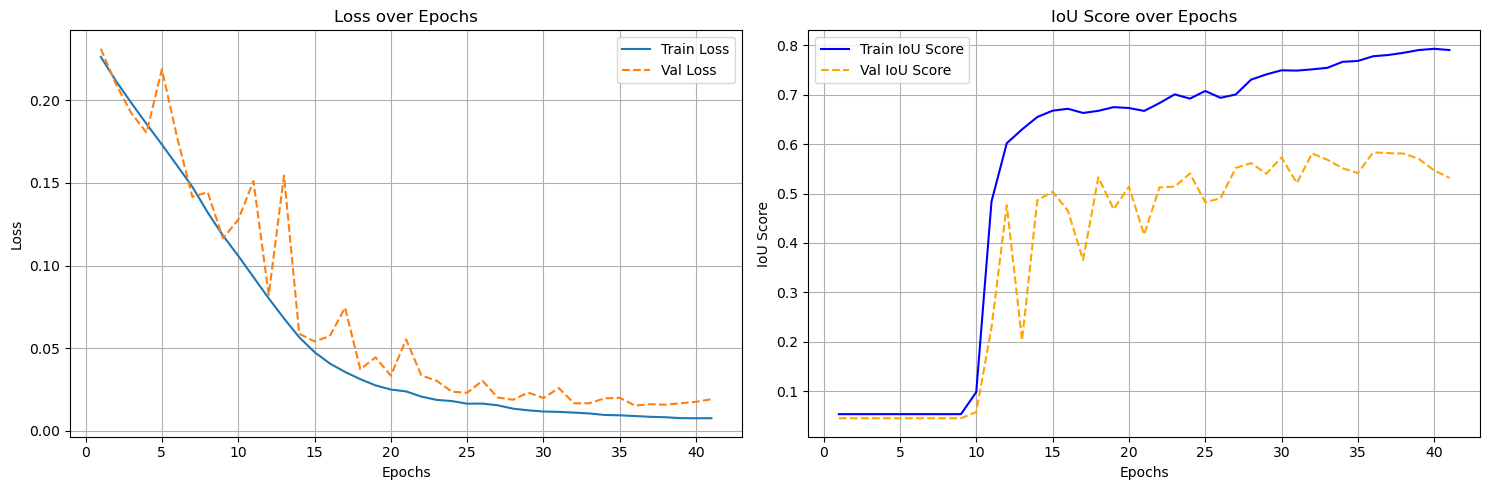

In [39]:
plotLoss_IOU(loss_df, iou_sore_df, loss_val_df, iou_score_val_df)

### Introduce L2 regularization to see the performance with MSE Loss

In [42]:
# initialize the directory and get the model
if train_flag:
    train_dir = train_dir_dict[imgType]
    mask_dir = train_mask_dir_dict[imgType]

    val_dir = val_dir_dict[imgType]
    mask_dir_val = val_mask_dir_dict[imgType]

    # initialize agent
    agent = Agent(train_flag,img_dir=train_dir,msk_dir=mask_dir,folder_path=folder_path, val_dir=val_dir, msk_dir_val=mask_dir_val, 
                  state='new', num_epochs=200, batchSize=30, bilinear=False)
    agent.initializeUnet()

     # load custom dataset
    train_loader, val_loader = agent.loadCustomData()

mps
Initialize Custom Data
Augmentation ::: False
Train flag:: True
loader root directory:: /Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation/train_data_edema_SAGIR
Total Size ::: 559
Initialize Custom Data
Total Size val::: 116


In [43]:
# run the model and get the predictions
if train_flag:
    # run the model
    loss_df, prediction_batch, iou_sore_df, loss_val_df, iou_score_val_df, prediction_batch_val = agent.runModel(train_loader, val_loader, 
                                                                                                            earlyStop=True,
                                                                                                            L2Reg=True)

Epoch [1/200], Train( Loss: 0.1706, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1751, IoU_score: 0.0454 )
Epoch [2/200], Train( Loss: 0.1567, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1596, IoU_score: 0.0454 )
Epoch [3/200], Train( Loss: 0.1459, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1428, IoU_score: 0.0454 )
Epoch [4/200], Train( Loss: 0.1356, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1417, IoU_score: 0.0454 )
Epoch [5/200], Train( Loss: 0.1256, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1568, IoU_score: 0.0454 )
EarlyStopping counter: 1 out of 5
Epoch [6/200], Train( Loss: 0.1156, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1158, IoU_score: 0.0454 )
Epoch [7/200], Train( Loss: 0.1059, IoU_score: 0.0914 ) ::: Validation ( Loss: 0.1552, IoU_score: 0.2294 )
EarlyStopping counter: 1 out of 5
Epoch [8/200], Train( Loss: 0.0967, IoU_score: 0.4913 ) ::: Validation ( Loss: 0.1070, IoU_score: 0.3368 )
Epoch [9/200], Train( Loss: 0.0870, IoU_score: 0.5774 ) ::: Validation ( Los

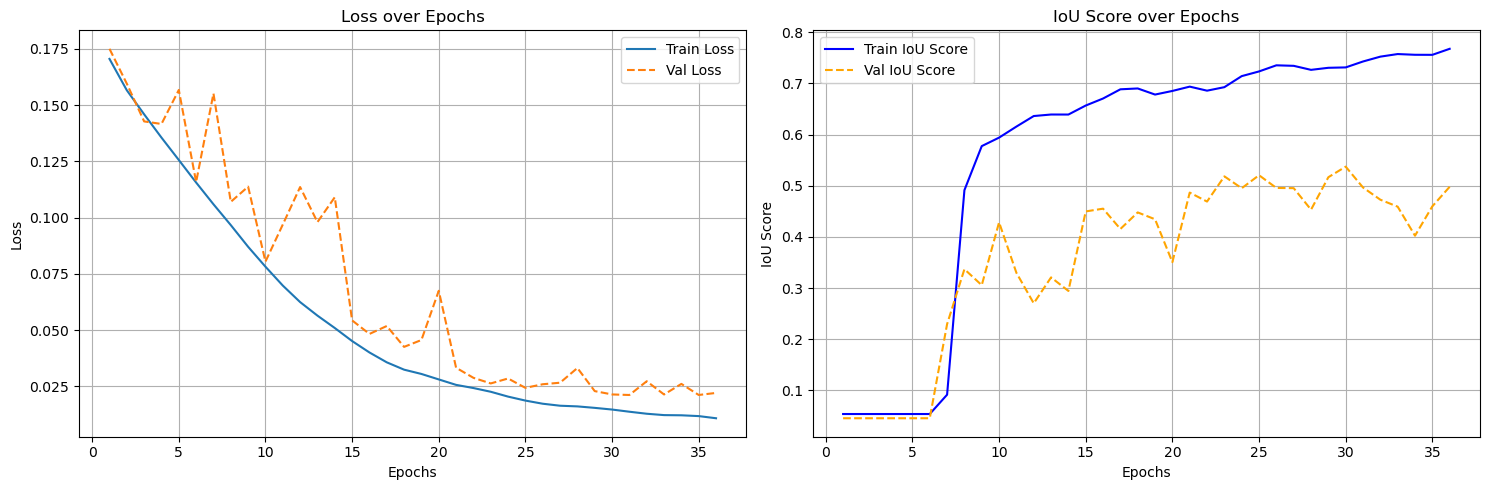

In [44]:
plotLoss_IOU(loss_df, iou_sore_df, loss_val_df, iou_score_val_df)

### Reduce the learning rate to 0.00001

In [46]:
if train_flag:
    train_dir = train_dir_dict[imgType]
    mask_dir = train_mask_dir_dict[imgType]

    val_dir = val_dir_dict[imgType]
    mask_dir_val = val_mask_dir_dict[imgType]

    # initialize agent
    agent = Agent(train_flag,img_dir=train_dir,msk_dir=mask_dir,folder_path=folder_path, val_dir=val_dir, msk_dir_val=mask_dir_val, 
                  state='new', num_epochs=200, batchSize=30, bilinear=False)
    agent.initializeUnet()

     # load custom dataset
    train_loader, val_loader = agent.loadCustomData()

mps
Initialize Custom Data
Augmentation ::: False
Train flag:: True
loader root directory:: /Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation/train_data_edema_SAGIR
Total Size ::: 559
Initialize Custom Data
Total Size val::: 116


In [49]:
agent.model

UNet(
  (encoder1): Res2NetSEBlock(
    (res2net): Res2NetBlock(
      (convs): ModuleList(
        (0): Conv2d(1, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1-3): 3 x Conv2d(2, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (conv_out): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (se): SEBlock(
      (fc1): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
      (fc2): Conv2d(1, 8, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (encoder2): Res2NetSEBlock(
    (res2net): Res2NetBlock(
      (convs): ModuleList(
        (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1-3): 3 x Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (conv_out): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (s

In [47]:
if train_flag:
    # run the model
    loss_df, prediction_batch, iou_sore_df, loss_val_df, iou_score_val_df, prediction_batch_val = agent.runModel(train_loader, val_loader, 
                                                                                                            earlyStop=True,
                                                                                                            L2Reg=True)

Epoch [1/200], Train( Loss: 0.2108, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.2101, IoU_score: 0.0454 )
Epoch [2/200], Train( Loss: 0.1972, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1902, IoU_score: 0.0454 )
Epoch [3/200], Train( Loss: 0.1835, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1737, IoU_score: 0.0454 )
Epoch [4/200], Train( Loss: 0.1717, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1659, IoU_score: 0.0454 )
Epoch [5/200], Train( Loss: 0.1599, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1620, IoU_score: 0.0454 )
Epoch [6/200], Train( Loss: 0.1488, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1399, IoU_score: 0.0454 )
Epoch [7/200], Train( Loss: 0.1373, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1297, IoU_score: 0.0454 )
Epoch [8/200], Train( Loss: 0.1262, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1760, IoU_score: 0.0454 )
EarlyStopping counter: 1 out of 5
Epoch [9/200], Train( Loss: 0.1155, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1288, IoU_score: 0.0454 )
Epo

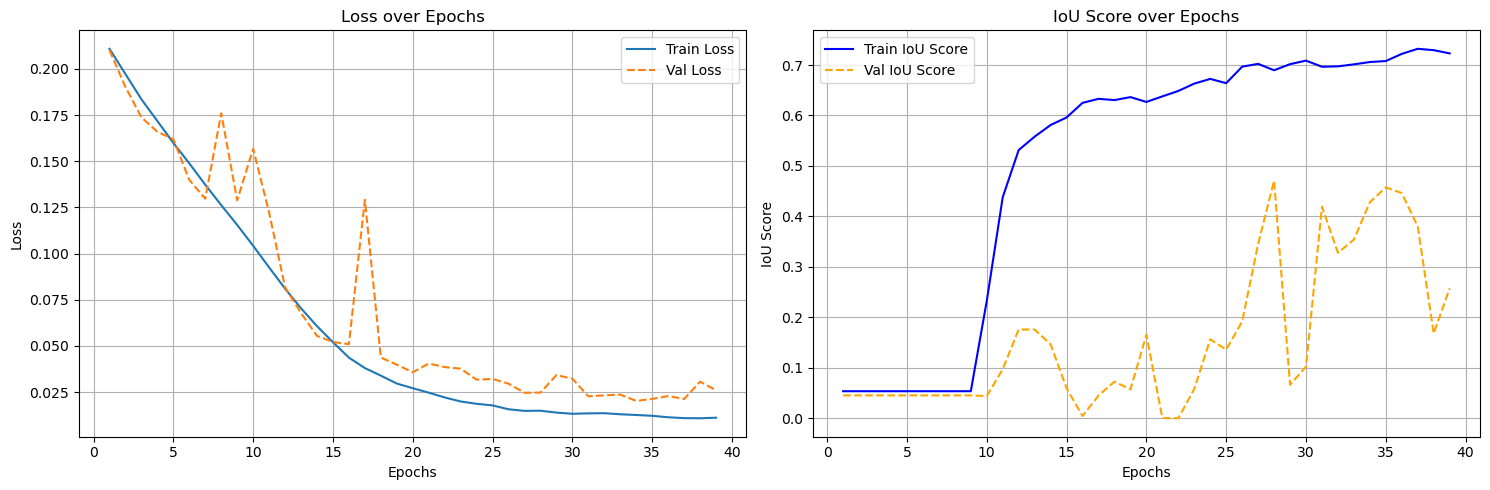

In [48]:
plotLoss_IOU(loss_df, iou_sore_df, loss_val_df, iou_score_val_df)

### changes the filters for the architecture to 32-64-128-256-512 and lr to 0.0001

In [14]:
if train_flag:
    train_dir = train_dir_dict[imgType]
    mask_dir = train_mask_dir_dict[imgType]

    val_dir = val_dir_dict[imgType]
    mask_dir_val = val_mask_dir_dict[imgType]

    # initialize agent
    agent = Agent(train_flag,img_dir=train_dir,msk_dir=mask_dir,folder_path=folder_path, val_dir=val_dir, msk_dir_val=mask_dir_val, 
                  state='new', num_epochs=200, batchSize=30, bilinear=False)
    agent.initializeUnet()

     # load custom dataset
    train_loader, val_loader = agent.loadCustomData()

mps
Initialize Custom Data
Augmentation ::: False
Train flag:: True
loader root directory:: /Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation/train_data_edema_SAGIR
Total Size ::: 559
Initialize Custom Data
Total Size val::: 116


In [16]:
agent.model

UNet(
  (encoder1): Res2NetSEBlock(
    (res2net): Res2NetBlock(
      (convs): ModuleList(
        (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1-3): 3 x Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (conv_out): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (se): SEBlock(
      (fc1): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
      (fc2): Conv2d(4, 32, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (encoder2): Res2NetSEBlock(
    (res2net): Res2NetBlock(
      (convs): ModuleList(
        (0): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1-3): 3 x Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (conv_out): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [17]:
if train_flag:
    # run the model
    loss_df, prediction_batch, iou_sore_df, loss_val_df, iou_score_val_df, prediction_batch_val = agent.runModel(train_loader, val_loader, 
                                                                                                            earlyStop=True)

Epoch [1/200], Train( Loss: 0.2408, IoU_score: 0.0536 ) ::: Validation ( Loss: 0.2485, IoU_score: 0.0454 )
Epoch [2/200], Train( Loss: 0.2301, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.2437, IoU_score: 0.0454 )
Epoch [3/200], Train( Loss: 0.2182, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.2341, IoU_score: 0.0454 )
Epoch [4/200], Train( Loss: 0.2079, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.2666, IoU_score: 0.0454 )
EarlyStopping counter: 1 out of 5
Epoch [5/200], Train( Loss: 0.1995, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.2091, IoU_score: 0.0454 )
Epoch [6/200], Train( Loss: 0.1913, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1868, IoU_score: 0.0454 )
Epoch [7/200], Train( Loss: 0.1832, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1798, IoU_score: 0.0454 )
Epoch [8/200], Train( Loss: 0.1730, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1759, IoU_score: 0.0454 )
Epoch [9/200], Train( Loss: 0.1670, IoU_score: 0.0537 ) ::: Validation ( Loss: 0.1627, IoU_score: 0.0454 )
Epo

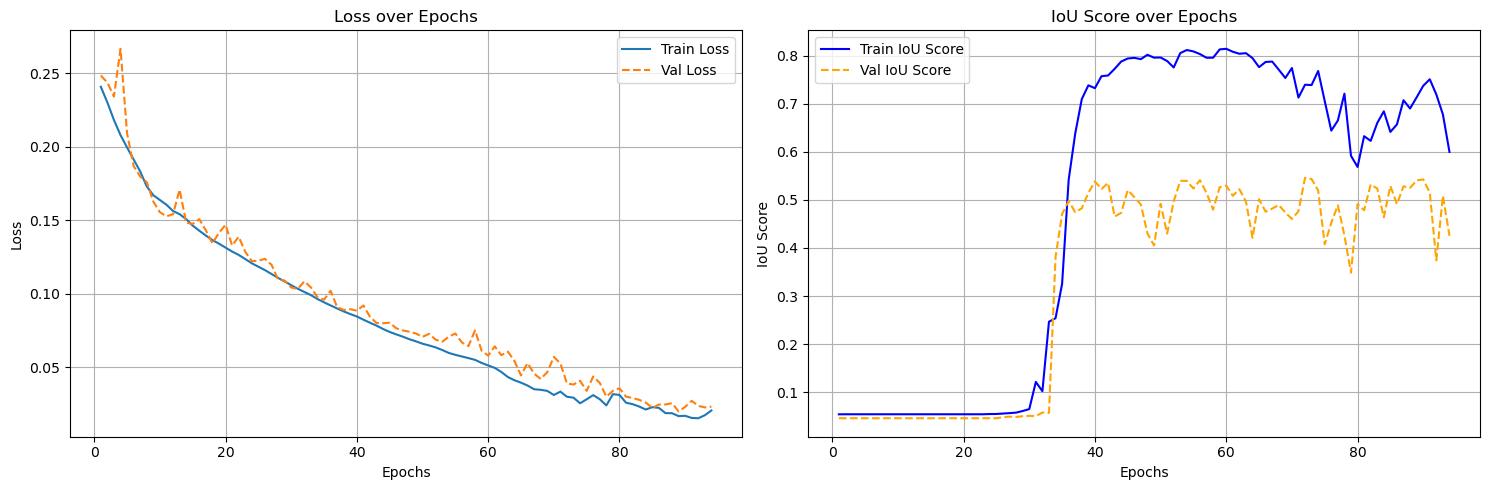

In [20]:
plotLoss_IOU(loss_df, iou_sore_df, loss_val_df, iou_score_val_df)

### Changing learning rate to 0.005 to see if the model is generalizaing better using both dice loss and l2 regularization 

In [22]:
# initialize agent
agent = Agent(train_flag,img_dir=train_dir,msk_dir=mask_dir,folder_path=folder_path, val_dir=val_dir, msk_dir_val=mask_dir_val, 
            state='new', num_epochs=100, batchSize=30, bilinear=False)
agent.initializeUnet()

# load custom dataset
train_loader, val_loader = agent.loadCustomData()

mps
Initialize Custom Data
Augmentation ::: False
Train flag:: True
loader root directory:: /Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation/train_data_edema_SAGIR
Total Size ::: 559
Initialize Custom Data
Total Size val::: 116


In [23]:
agent.model

UNet(
  (encoder1): Res2NetSEBlock(
    (res2net): Res2NetBlock(
      (convs): ModuleList(
        (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1-3): 3 x Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (conv_out): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (se): SEBlock(
      (fc1): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
      (fc2): Conv2d(4, 32, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (encoder2): Res2NetSEBlock(
    (res2net): Res2NetBlock(
      (convs): ModuleList(
        (0): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1-3): 3 x Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (conv_out): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [24]:
if train_flag:
    # run the model
    loss_df, prediction_batch, iou_sore_df, loss_val_df, iou_score_val_df, prediction_batch_val = agent.runModel(train_loader, val_loader, 
                                                                                                            earlyStop=True,
                                                                                                            L2Reg=True,
                                                                                                            loss='DICE')

Epoch [1/100], Train( Loss: 0.8241, IoU_score: 0.1379 ) ::: Validation ( Loss: 0.9314, IoU_score: 0.0000 )
Epoch [2/100], Train( Loss: 0.6804, IoU_score: 0.2993 ) ::: Validation ( Loss: 0.6211, IoU_score: 0.3081 )
Epoch [3/100], Train( Loss: 0.4802, IoU_score: 0.4164 ) ::: Validation ( Loss: 0.5147, IoU_score: 0.3381 )
Epoch [4/100], Train( Loss: 0.3981, IoU_score: 0.4484 ) ::: Validation ( Loss: 0.6269, IoU_score: 0.2156 )
EarlyStopping counter: 1 out of 5
Epoch [5/100], Train( Loss: 0.3679, IoU_score: 0.4729 ) ::: Validation ( Loss: 0.9998, IoU_score: 0.0000 )
EarlyStopping counter: 2 out of 5
Epoch [6/100], Train( Loss: 0.3624, IoU_score: 0.4730 ) ::: Validation ( Loss: 0.7429, IoU_score: 0.1359 )
EarlyStopping counter: 3 out of 5
Epoch [7/100], Train( Loss: 0.3448, IoU_score: 0.4921 ) ::: Validation ( Loss: 0.6270, IoU_score: 0.2241 )
EarlyStopping counter: 4 out of 5
Epoch [8/100], Train( Loss: 0.3220, IoU_score: 0.5145 ) ::: Validation ( Loss: 0.4195, IoU_score: 0.4070 )
Epoch [9

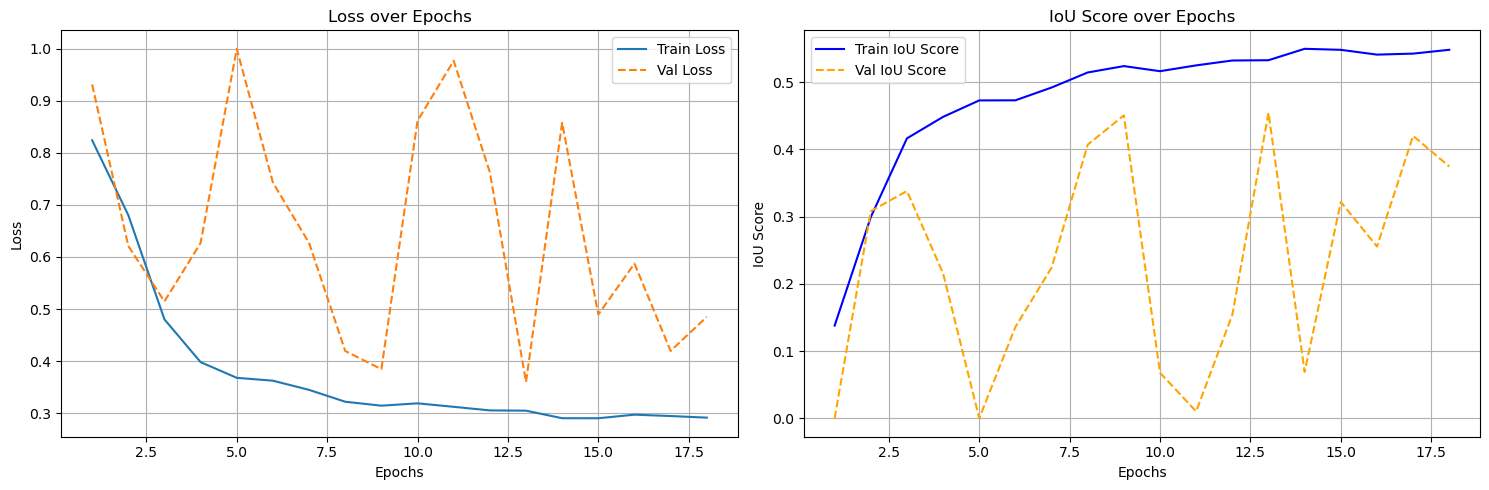

In [25]:
plotLoss_IOU(loss_df, iou_sore_df, loss_val_df, iou_score_val_df)

### Change learning rate to 0.001 and try Reduced LR on plateau

In [71]:
# initialize agent
agent = Agent(train_flag,img_dir=train_dir,msk_dir=mask_dir,folder_path=folder_path, val_dir=val_dir, msk_dir_val=mask_dir_val, 
            state='new', num_epochs=100, batchSize=30, bilinear=False)
agent.initializeUnet()

# load custom dataset
train_loader, val_loader = agent.loadCustomData()

mps
Initialize Custom Data
Augmentation ::: False
Train flag:: True
loader root directory:: /Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation/train_data_edema_SAGIR
Total Size ::: 559
Initialize Custom Data
Total Size val::: 116


In [72]:
loss_df, prediction_batch, iou_sore_df, loss_val_df, iou_score_val_df, prediction_batch_val = agent.runModel(train_loader, val_loader, 
                                                                                                            earlyStop=True,
                                                                                                            L2Reg=True,
                                                                                                            loss='DICE')

Epoch [1/100], Train( Loss: 0.8661, IoU_score: 0.0668 ) ::: Validation ( Loss: 0.9277, IoU_score: 0.0454 )
Epoch [2/100], Train( Loss: 0.8287, IoU_score: 0.1171 ) ::: Validation ( Loss: 0.9204, IoU_score: 0.0454 )
Epoch [3/100], Train( Loss: 0.7996, IoU_score: 0.1922 ) ::: Validation ( Loss: 0.8376, IoU_score: 0.2433 )
Epoch [4/100], Train( Loss: 0.7734, IoU_score: 0.2373 ) ::: Validation ( Loss: 0.8128, IoU_score: 0.2309 )
Epoch [5/100], Train( Loss: 0.7351, IoU_score: 0.3102 ) ::: Validation ( Loss: 0.8314, IoU_score: 0.1312 )
EarlyStopping counter: 1 out of 5
Epoch [6/100], Train( Loss: 0.6872, IoU_score: 0.3613 ) ::: Validation ( Loss: 0.7141, IoU_score: 0.3638 )
Epoch [7/100], Train( Loss: 0.6300, IoU_score: 0.3974 ) ::: Validation ( Loss: 0.7536, IoU_score: 0.2277 )
Learning rate has been updated to:: 0.0005
EarlyStopping counter: 1 out of 5
Epoch [8/100], Train( Loss: 0.5682, IoU_score: 0.4344 ) ::: Validation ( Loss: 0.6337, IoU_score: 0.3471 )
Epoch [9/100], Train( Loss: 0.523

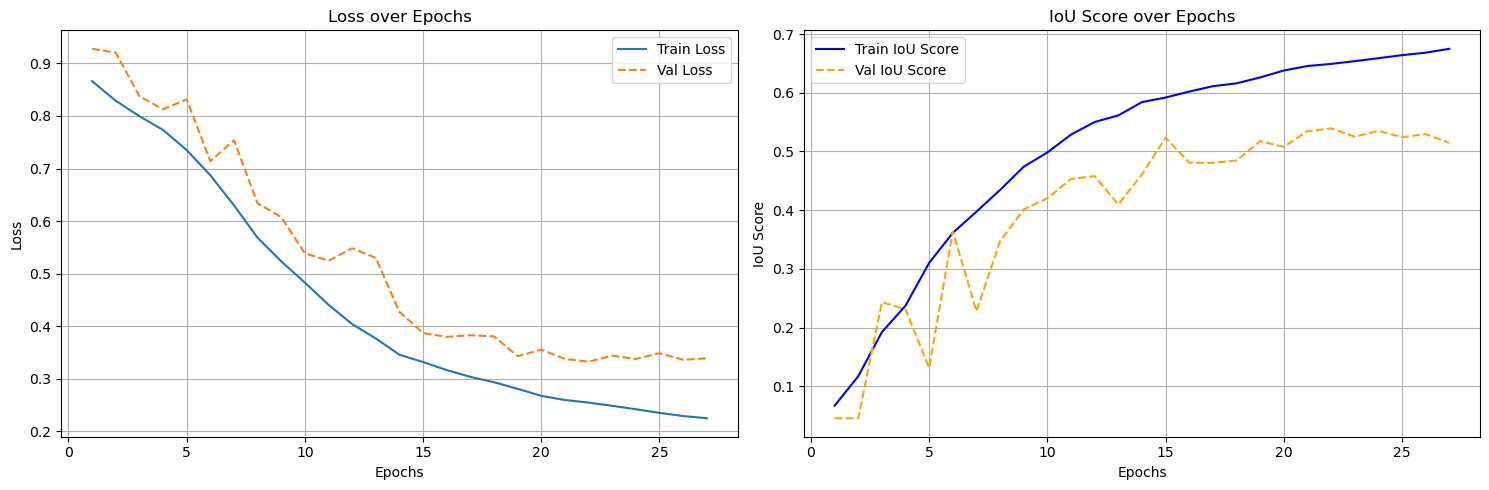

In [73]:
plotLoss_IOU(loss_df, iou_sore_df, loss_val_df, iou_score_val_df)

In [74]:
 # join the list of prediction lists 
predictions = list(chain(*prediction_batch))
predictions_val = list(chain(*prediction_batch_val))

P088 SAGIR_020.jpg


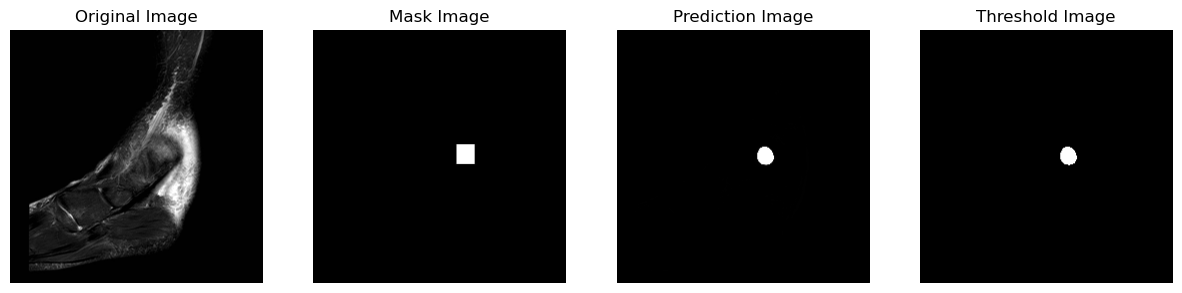

P089 SAGIR_012.jpg


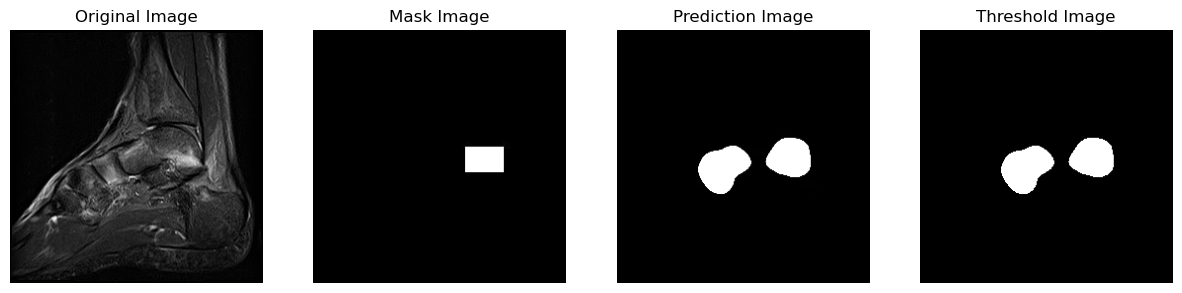

P047 SAGIR_014.jpg


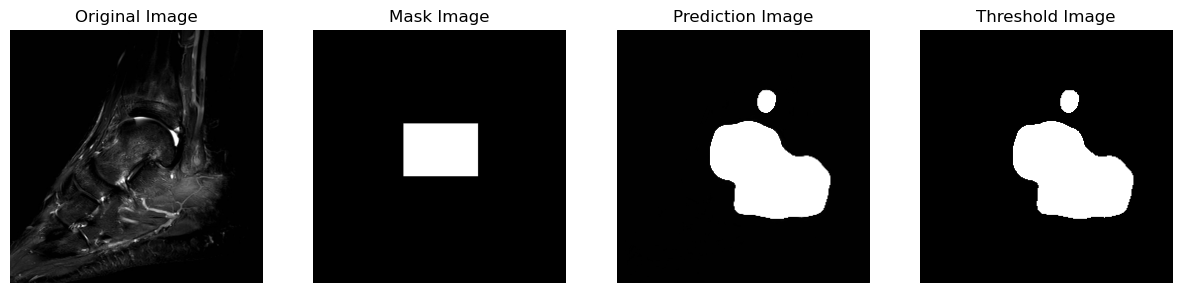

P009 SAGIR_013.jpg


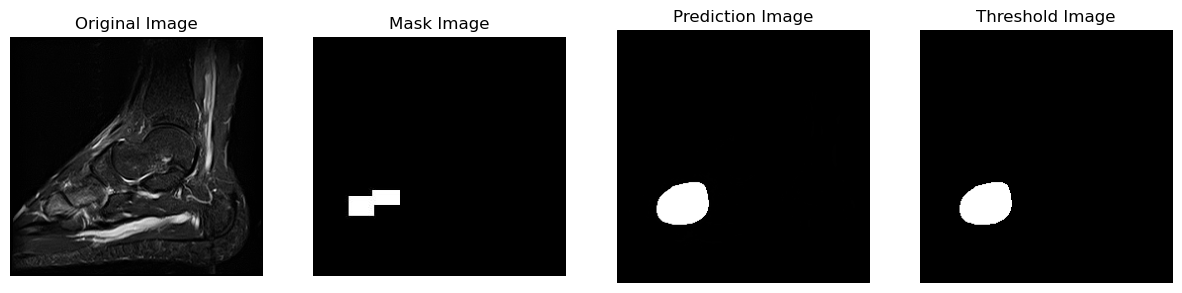

P034 SAGIR_012.jpg


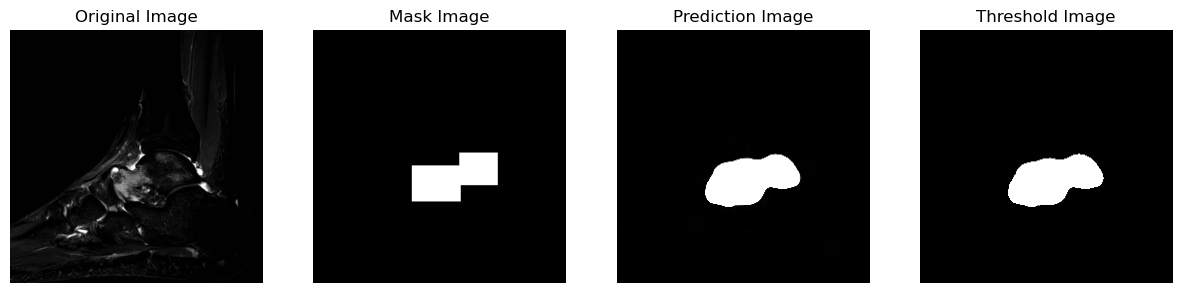

P023 SAGIR_012.jpg


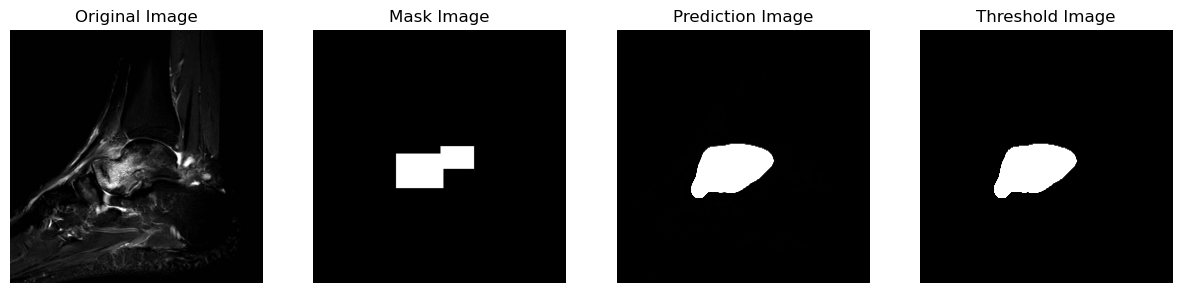

P079 SAGIR_004.jpg


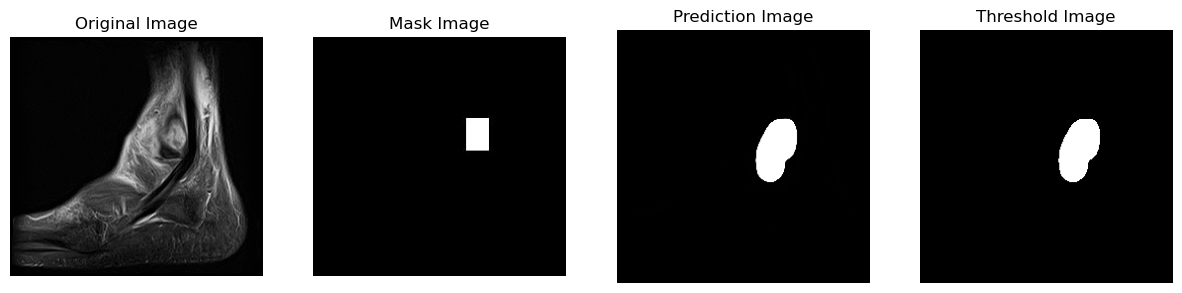

P050 SAGIR_014.jpg


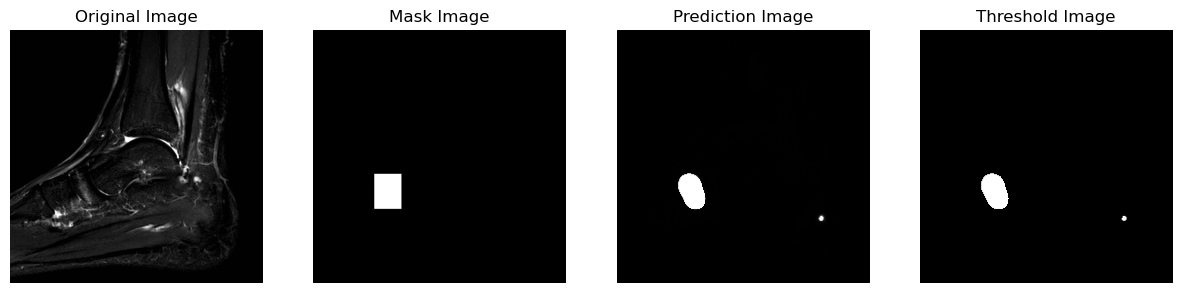

P036 SAGIR_018.jpg


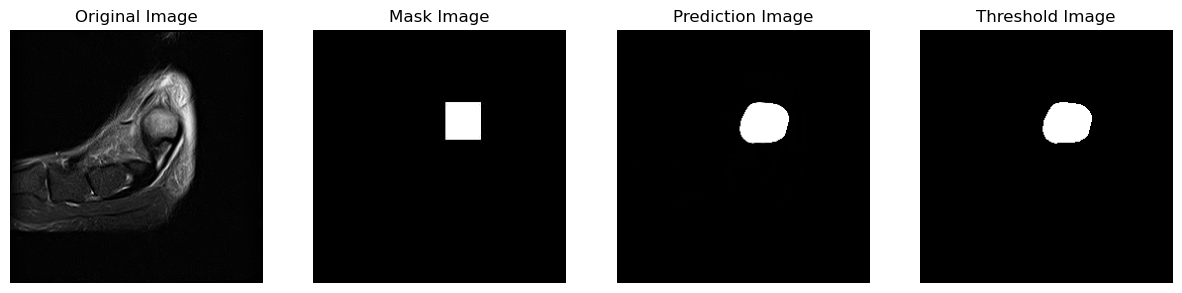

P050 SAGIR_015.jpg


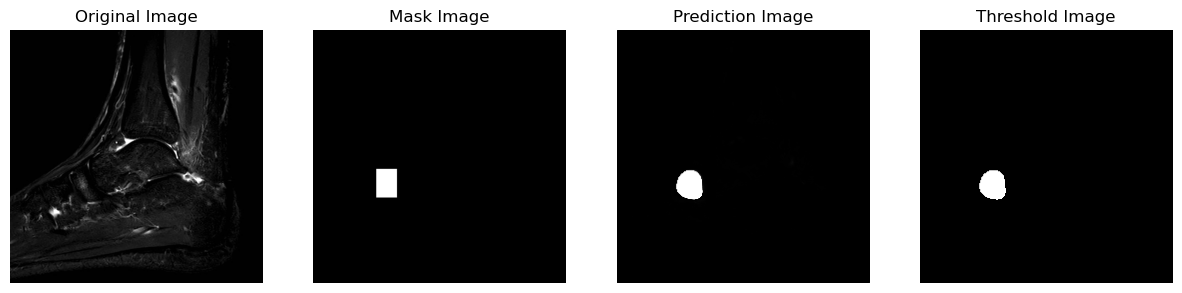

In [75]:
agent.printPrediction(loader=train_loader, preds=predictions, idx=6)

In [83]:
#folder_path = os.path.dirname(folder_path)

# write the data to the files and save the net
w_path = os.path.join(folder_path,"Result","IoUScore_edema_ES.csv")
agent.writeRun(iou_sore_df,w_path)

# write the loss data
w_path = os.path.join(folder_path,"Result","LossOutput_edema_ES.csv")
agent.writeRun(loss_df,w_path)

# save the net
agent.save_net(file_name='UNet_edemaES')

### Test the model with test data

In [8]:
train_flag = False

# set the directories
test_dir = test_dir_dict[imgType]
mask_dir_test = test_mask_dir_dict[imgType]

# initialize the agent , pass the batchSize as the no.of images in the test , state as old to initialize existing model
agent_test = Agent(train_flag,img_dir=test_dir,msk_dir=mask_dir_test,folder_path=folder_path, state='old',num_epochs=1, batchSize=185, bilinear=False)
agent_test.initializeUnet('UNet_edemaESOCT 12, 2024 02_50PM')

test_loader = agent_test.loadCustomData()

mps
Initialize Custom Data
Augmentation ::: False
Train flag:: False
loader root directory:: /Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation/test_data_edema_SAGIR
Total Size ::: 185


In [9]:
# run the model for test and check the iou and histogram
prediction_batch_test, iou_score_batch_test, iou_score_each_test = agent_test.runModel(test_loader)
print(len(iou_score_each_test))
# plot the testing iou histogram
plotTest_IOU(iou_score_each_test)

RuntimeError: MPS backend out of memory (MPS allocated: 26.95 GB, other allocations: 7.84 MB, max allowed: 27.20 GB). Tried to allocate 2.89 GB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

### Try with some augmentation data

In [64]:
%run Agent.ipynb
# initialize agent
agent = Agent(train_flag,img_dir=train_dir,msk_dir=mask_dir,folder_path=folder_path, val_dir=val_dir, msk_dir_val=mask_dir_val, 
            state='new', num_epochs=100, batchSize=30, bilinear=False)
agent.initializeUnet()

# load custom dataset
train_loader, val_loader = agent.loadCustomData(augment=True)

mps
Initialize Custom Data
Augmentation Initialized
Augmentation ::: True
Train flag:: True
loader root directory:: /Users/jiten/Masters/WorkPlace/MRI_Multi_Image_Segmentation/train_data_edema_SAGIR
Total Size ::: 1118
Initialize Custom Data
Total Size val::: 116


In [65]:
loss_df, prediction_batch, iou_sore_df, loss_val_df, iou_score_val_df, prediction_batch_val = agent.runModel(train_loader, val_loader, 
                                                                                                            earlyStop=True,
                                                                                                            L2Reg=True,
                                                                                                            loss='DICE')

Epoch [1/100], Train( Loss: 0.8462, IoU_score: 0.0618 ) ::: Validation ( Loss: 0.9314, IoU_score: 0.0454 )
Epoch [2/100], Train( Loss: 0.7985, IoU_score: 0.2251 ) ::: Validation ( Loss: 0.9335, IoU_score: 0.0043 )
EarlyStopping counter: 1 out of 5
Epoch [3/100], Train( Loss: 0.7377, IoU_score: 0.3077 ) ::: Validation ( Loss: 0.7302, IoU_score: 0.2965 )
Epoch [4/100], Train( Loss: 0.6363, IoU_score: 0.3736 ) ::: Validation ( Loss: 0.7184, IoU_score: 0.2533 )
Epoch [5/100], Train( Loss: 0.4970, IoU_score: 0.4557 ) ::: Validation ( Loss: 0.6444, IoU_score: 0.3021 )
Epoch [6/100], Train( Loss: 0.4338, IoU_score: 0.4532 ) ::: Validation ( Loss: 0.9906, IoU_score: 0.0017 )
EarlyStopping counter: 1 out of 5
Epoch [7/100], Train( Loss: 0.3669, IoU_score: 0.4988 ) ::: Validation ( Loss: 0.8291, IoU_score: 0.0878 )
Learning rate has been updated to:: 0.0005
EarlyStopping counter: 2 out of 5
Epoch [8/100], Train( Loss: 0.3267, IoU_score: 0.5315 ) ::: Validation ( Loss: 0.3760, IoU_score: 0.4788 )

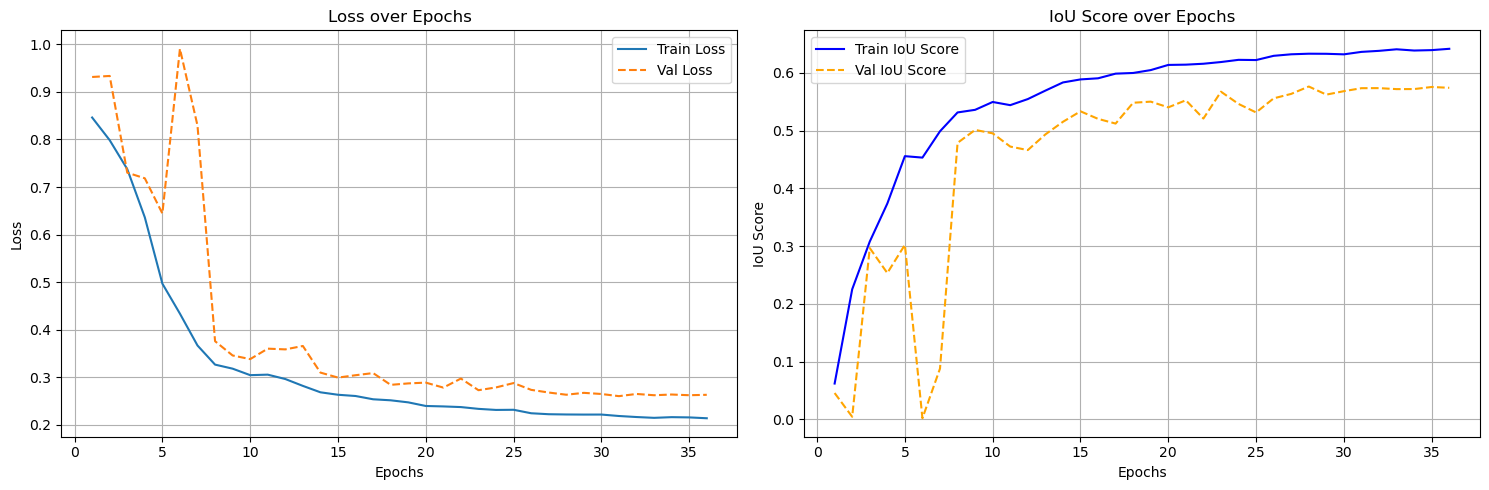

In [66]:
plotLoss_IOU(loss_df, iou_sore_df, loss_val_df, iou_score_val_df)

In [67]:
 # join the list of prediction lists 
predictions = list(chain(*prediction_batch))
predictions_val = list(chain(*prediction_batch_val))

P088 SAGIR_020.jpg


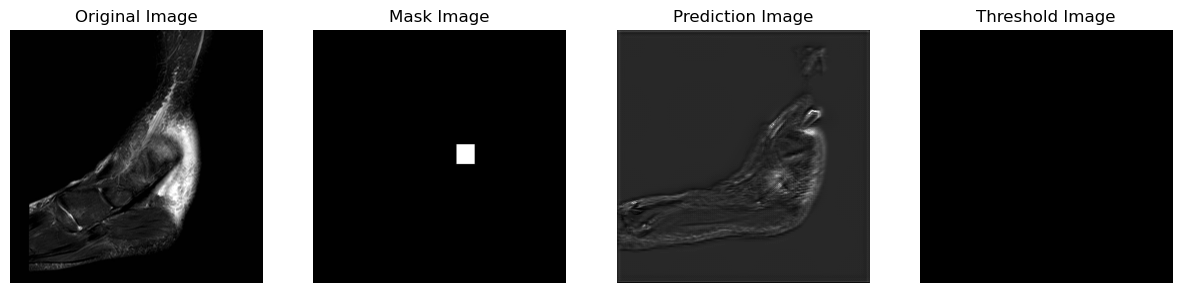

P089 SAGIR_012.jpg


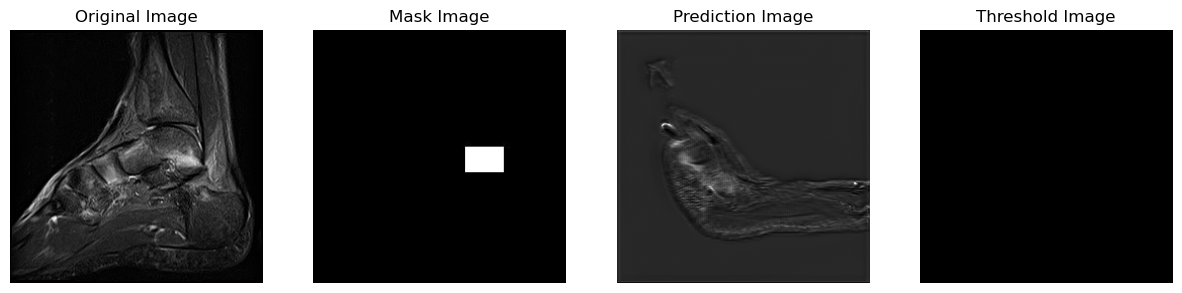

P047 SAGIR_014.jpg


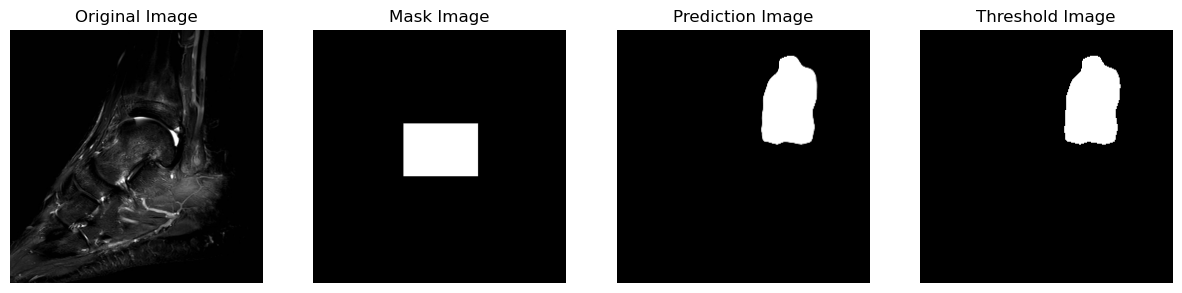

P009 SAGIR_013.jpg


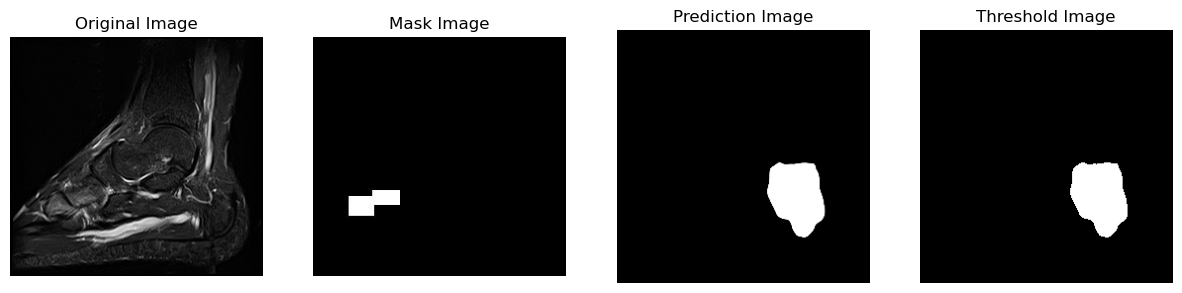

P034 SAGIR_012.jpg


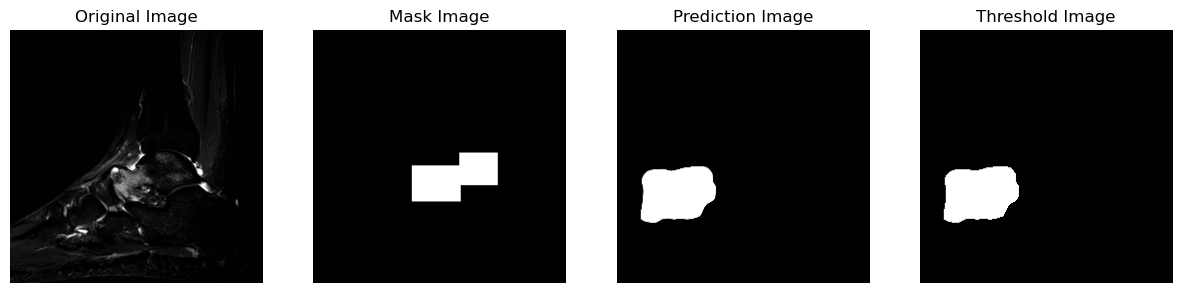

P023 SAGIR_012.jpg


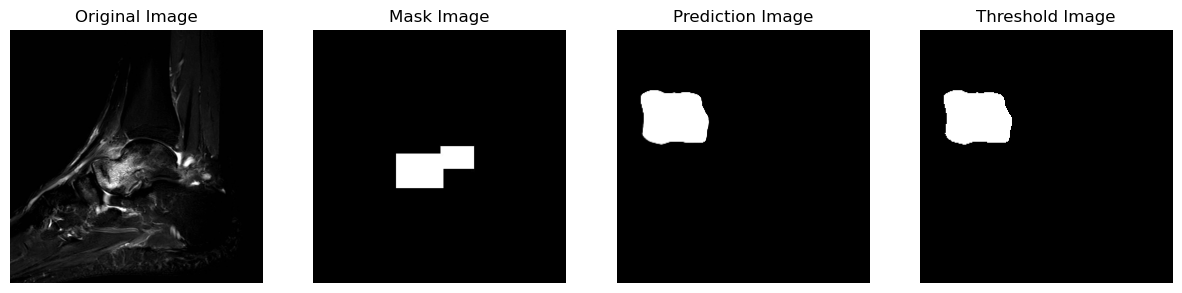

P079 SAGIR_004.jpg


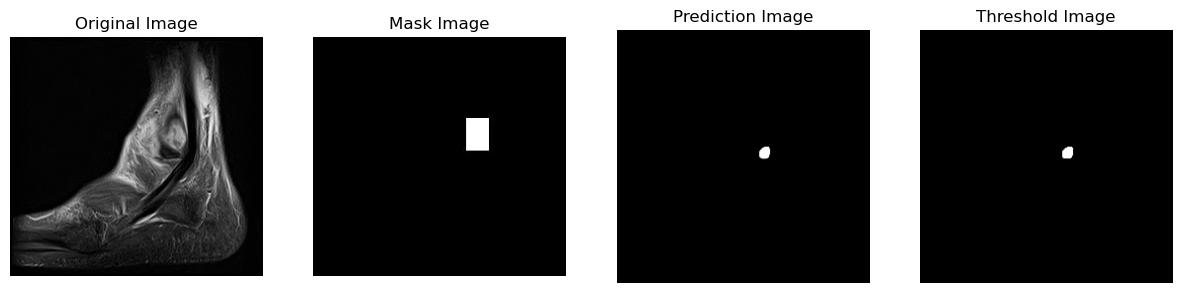

P050 SAGIR_014.jpg


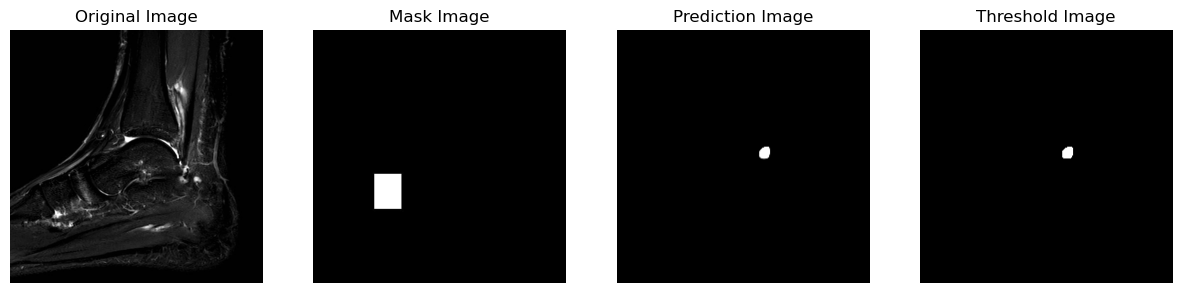

P036 SAGIR_018.jpg


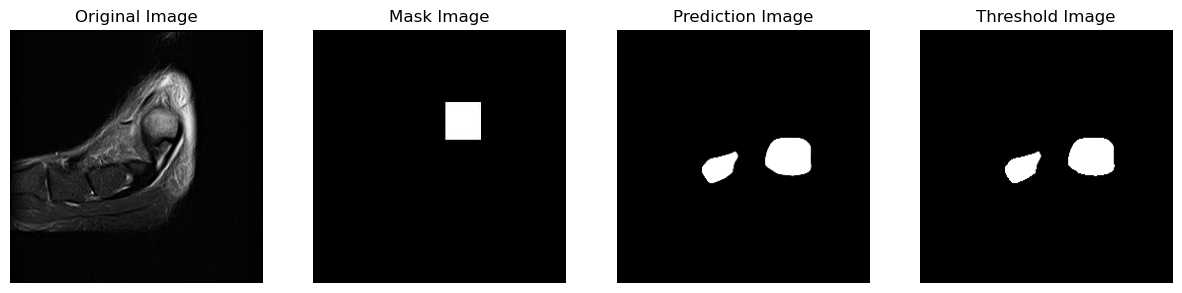

P050 SAGIR_015.jpg


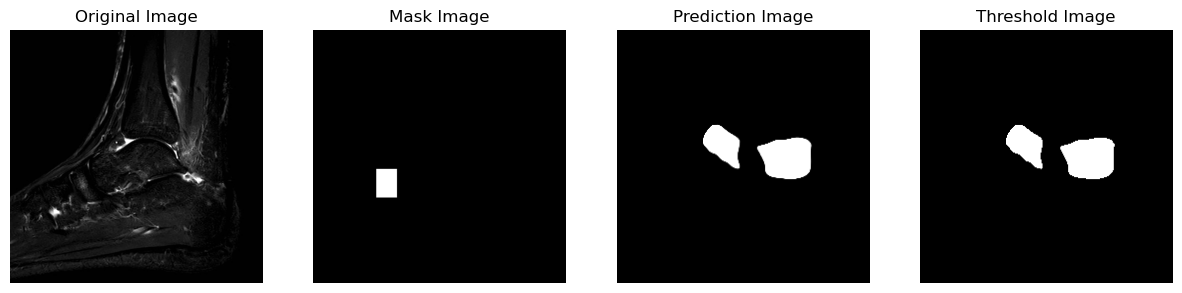

In [70]:
agent.printPrediction(loader=train_loader, preds=predictions, idx=6)

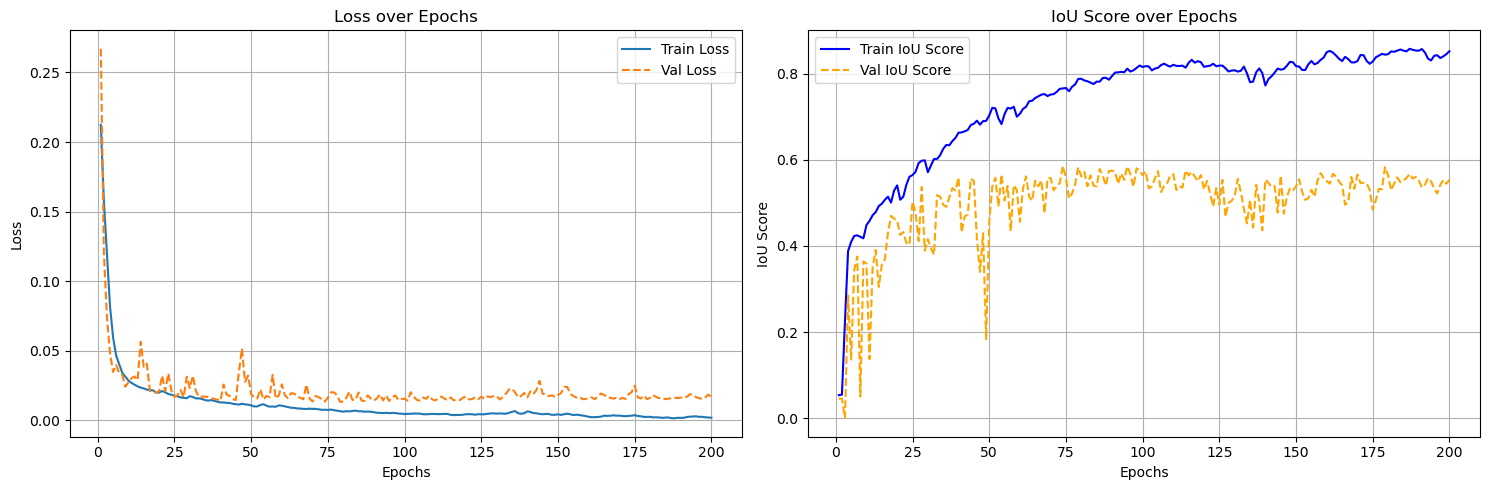

In [13]:
# this output was with higher filters ran for 3000 mins
plotLoss_IOU(loss_df, iou_sore_df, loss_val_df, iou_score_val_df)

In [16]:
 # join the list of prediction lists 
predictions = list(chain(*prediction_batch))
predictions_val = list(chain(*prediction_batch_val))

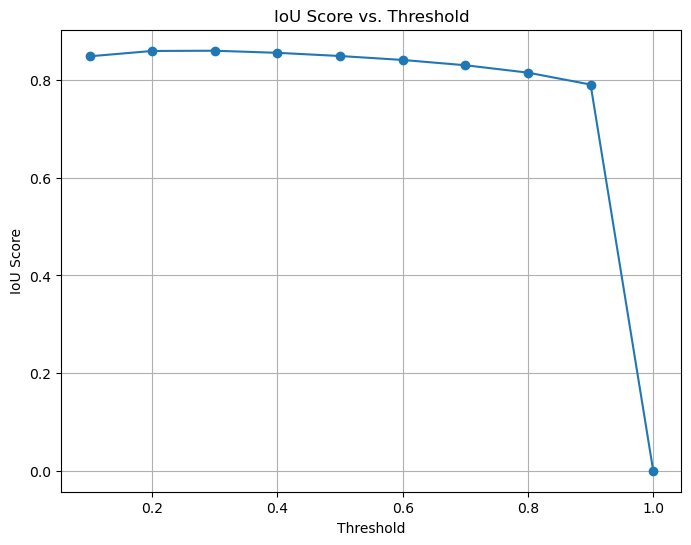

In [19]:
# check for optimal threshold for deciding the threshold for training
if train_flag:
    # compute an optimal threshold
    iou_vs_thresh = agent.optimalThresVsIoU(train_loader, predictions)
    plotOptimalThresh(iou_vs_thresh)

P088 SAGIR_020.jpg


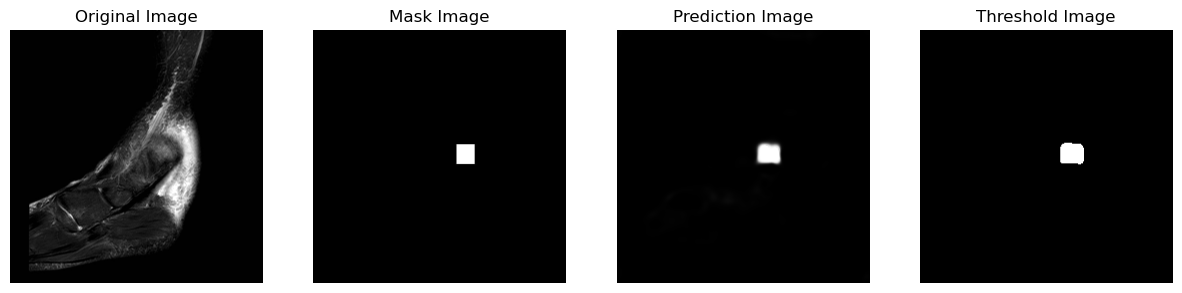

P089 SAGIR_012.jpg


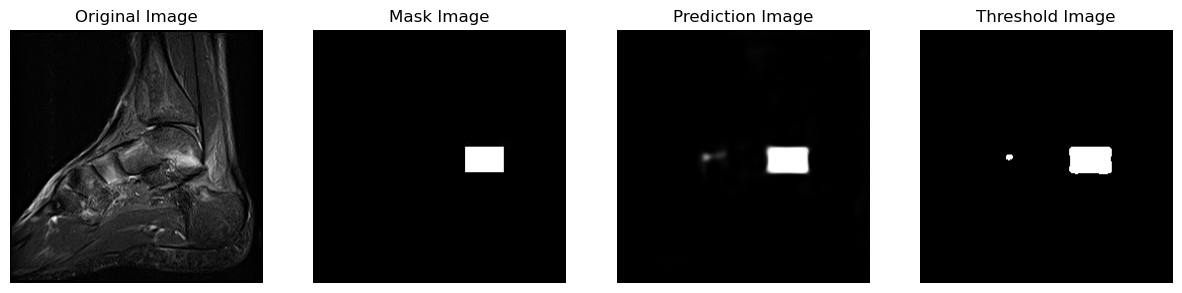

P047 SAGIR_014.jpg


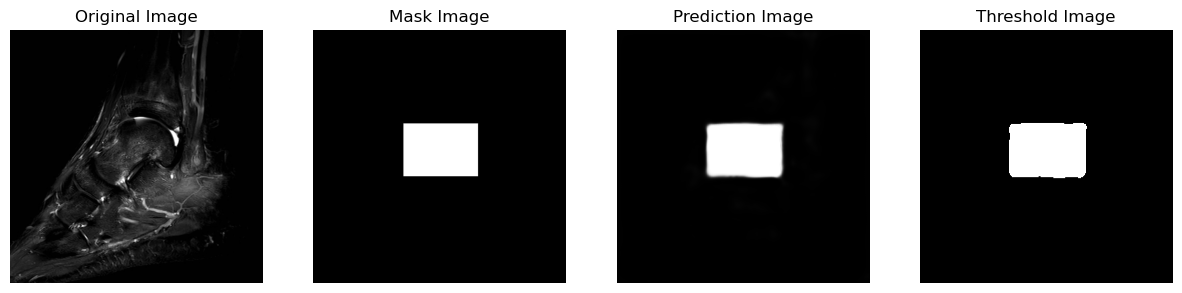

P009 SAGIR_013.jpg


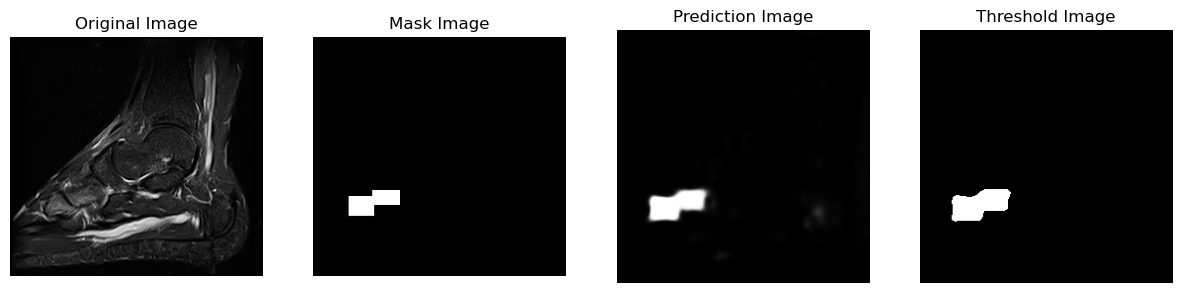

P034 SAGIR_012.jpg


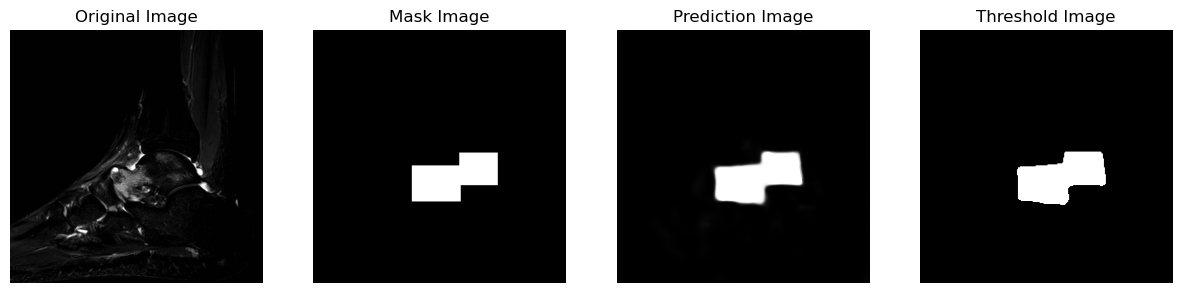

P023 SAGIR_012.jpg


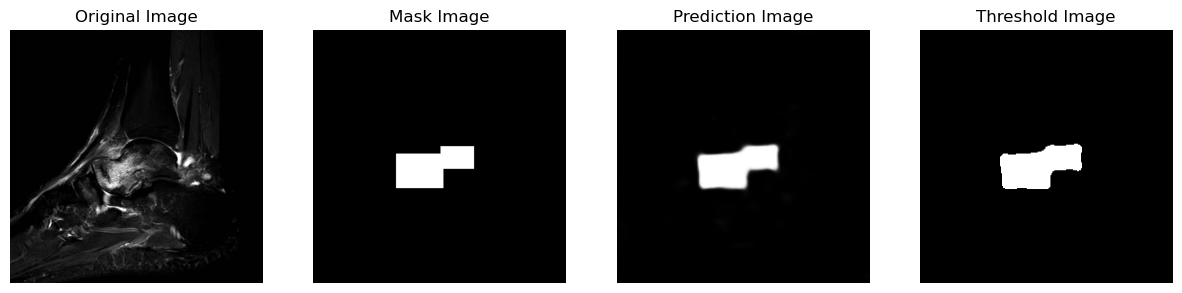

P079 SAGIR_004.jpg


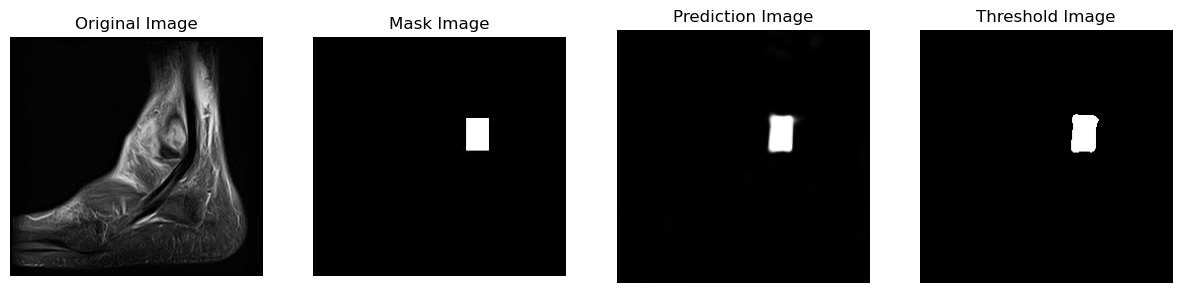

P050 SAGIR_014.jpg


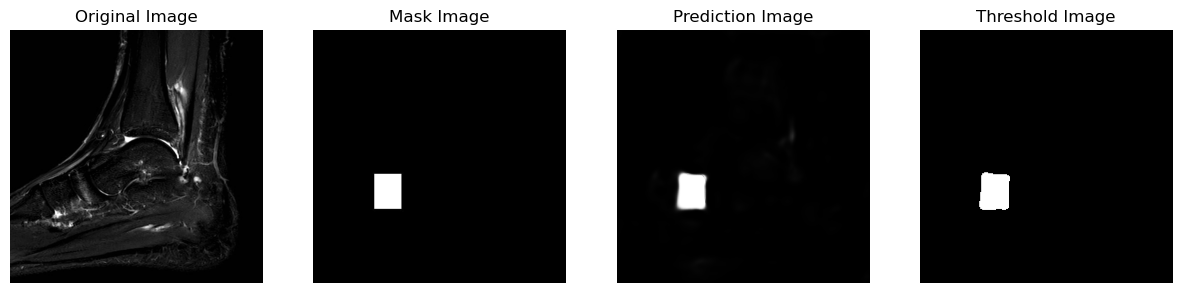

P036 SAGIR_018.jpg


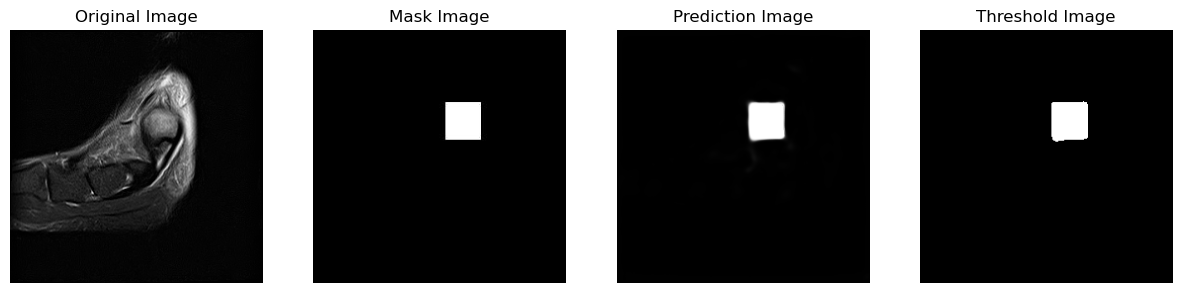

P050 SAGIR_015.jpg


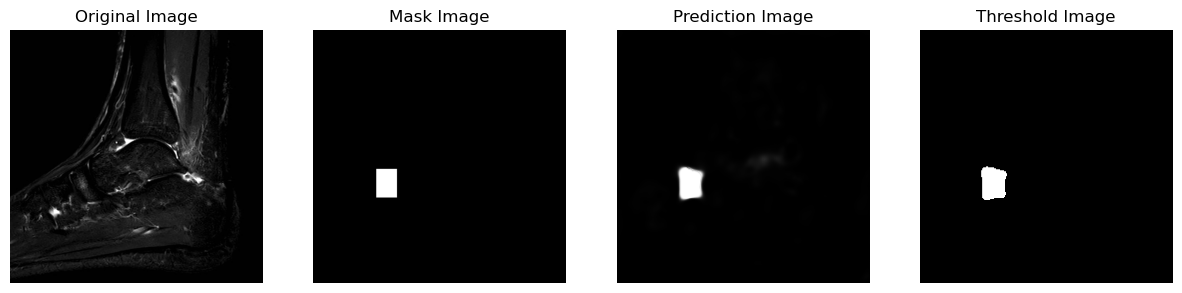

In [20]:
# writ the data
if train_flag:
    # plot few results
    agent.printPrediction(loader=train_loader, preds=predictions)

In [23]:
folder_path = os.path.dirname(folder_path)

In [24]:
# write the data to the files and save the net
w_path = os.path.join(folder_path,"Result","IoUScore_edema.csv")
agent.writeRun(iou_sore_df,w_path)

# write the loss data
w_path = os.path.join(folder_path,"Result","LossOutput_edema.csv")
agent.writeRun(loss_df,w_path)

# save the net
agent.save_net(file_name='UNet_edema')